##Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime


In [2]:
now = datetime.now()
ticker = 'AAPL'
start = datetime(now.year-10,now.month,now.day)
end = now

df = yf.download(ticker,start,end)
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000
2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600
2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000
2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800
2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400
...,...,...,...,...,...
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000
2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600
2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000
2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800
2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400


In [4]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900
2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900
2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900
2026-06-25,275.149994,288.799988,273.750000,287.399994,107013700
2026-06-26,283.779999,285.950012,274.209991,275.000000,261693600


#Data exploration & Visualization

In [5]:
type(df)

pandas.DataFrame

In [6]:
df.shape

(2512, 5)

In [7]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2512.000000,2512.000000,2512.000000,2512.000000,2.512000e+03
mean,126.207404,127.478451,124.833543,126.100426,9.582722e+07
std,77.711423,78.491612,76.904543,77.663082,5.466396e+07
min,21.490124,21.524272,21.314833,21.392234,1.791060e+07
25%,45.514274,45.897533,45.073280,45.482841,5.666672e+07
50%,130.847710,132.224340,129.656159,131.256468,8.406920e+07
75%,182.324917,183.834972,180.456677,181.873807,1.158380e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [9]:
df.Close

Ticker,AAPL
Date,
2016-06-29,21.490124
2016-06-30,21.763300
2016-07-01,21.829327
2016-07-05,21.624437
2016-07-06,21.747370
...,...
2026-06-22,297.010010
2026-06-23,294.299988
2026-06-24,293.079987


In [10]:
df = df.reset_index()

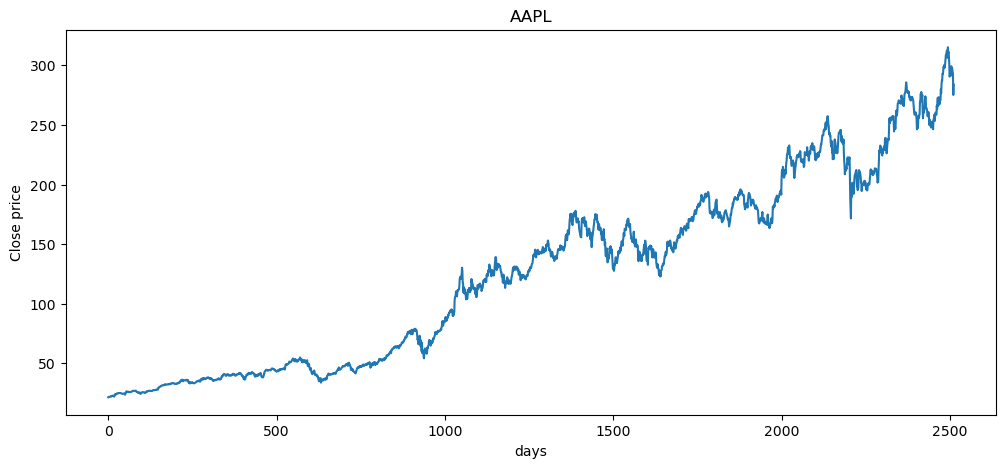

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel('days')
plt.ylabel('Close price');

In [12]:
#100 days MA

df['MA_100'] = df.Close.rolling(100).mean()
df['MA_100'].head(103)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
98           NaN
99     24.744922
100    24.783222
101    24.822633
102    24.861545
Name: MA_100, Length: 103, dtype: float64

In [13]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000,NaN
1,2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600,NaN
2,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN
3,2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800,NaN
4,2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400,NaN
...,...,...,...,...,...,...,...
2507,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750
2508,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106
2509,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,275.676895


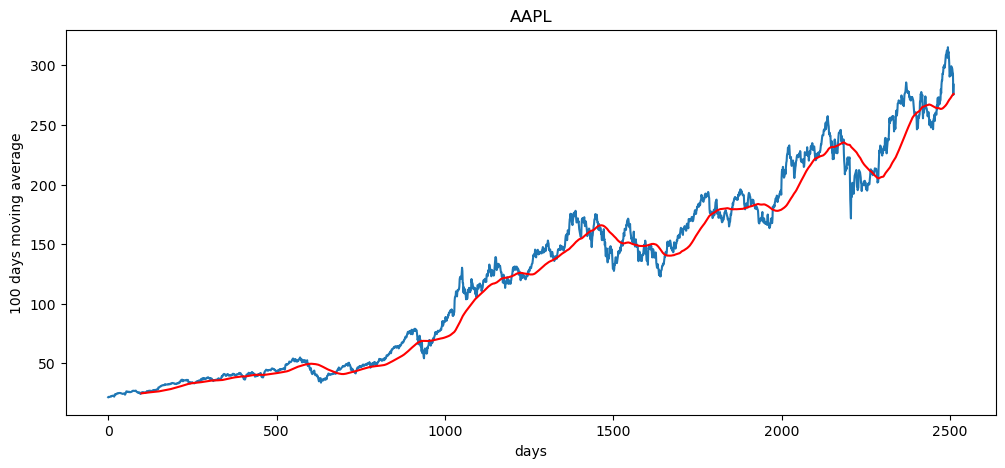

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r')
plt.title(ticker);
plt.xlabel('days')
plt.ylabel('100 days moving average');

In [15]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(204)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000,NaN,NaN
1,2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600,NaN,NaN
2,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN
3,2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800,NaN,NaN
4,2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400,NaN,NaN
...,...,...,...,...,...,...,...,...
199,2017-04-13,32.590374,32.897678,32.590374,32.789082,71291600,29.382467,27.063694
200,2017-04-17,32.770584,32.782138,32.548769,32.689713,66328400,29.456971,27.120097
201,2017-04-18,32.625031,32.819116,32.604236,32.673554,58790000,29.526178,27.174405


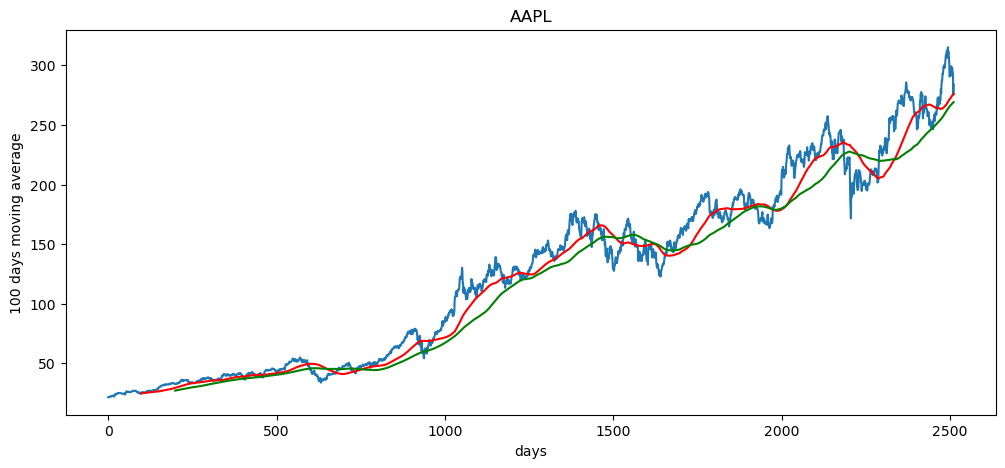

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df.Close);
plt.plot(df['MA_100'],'r')
plt.plot(df.MA_200,'g')
plt.title(ticker);
plt.xlabel('days');
plt.ylabel('100 days moving average');

##Calculating % in each trading session



In [17]:
df['percentage changed'] = df.Close.pct_change()
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,percentage changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000,NaN,NaN,NaN
1,2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600,NaN,NaN,0.012712
2,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN,0.003034
3,2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800,NaN,NaN,-0.009386
4,2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400,NaN,NaN,0.005685
...,...,...,...,...,...,...,...,...,...
2507,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750,268.089066,-0.003356
2508,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106,268.365048,-0.009124
2509,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,275.676895,268.635379,-0.004145


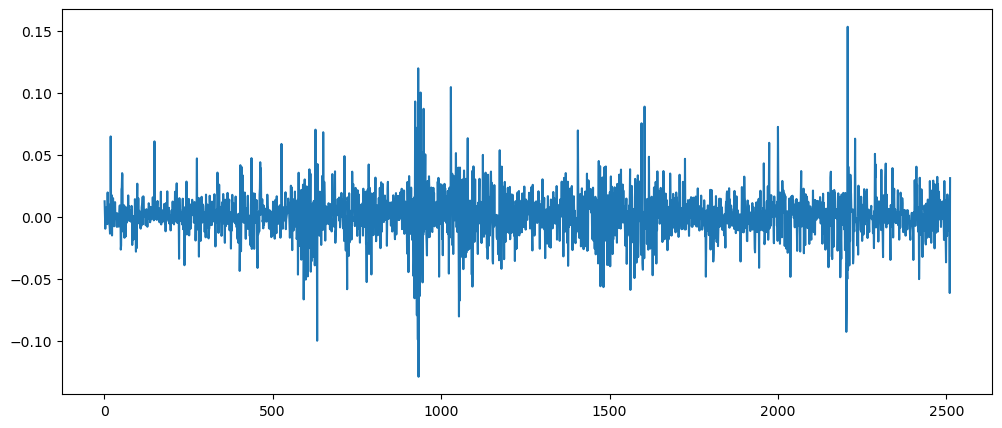

In [18]:
plt.figure(figsize=(12,5));
plt.plot(df['percentage changed']);

In [19]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,percentage changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-06-29,21.490124,21.524272,21.314833,21.392234,146124000,NaN,NaN,NaN
1,2016-06-30,21.763300,21.802000,21.467357,21.499227,143345600,NaN,NaN,0.012712
2,2016-07-01,21.829327,21.961364,21.701843,21.738266,104106000,NaN,NaN,0.003034
3,2016-07-05,21.624437,21.717775,21.503783,21.715498,110820800,NaN,NaN,-0.009386
4,2016-07-06,21.747370,21.776965,21.483297,21.535656,123796400,NaN,NaN,0.005685
...,...,...,...,...,...,...,...,...,...
2507,2026-06-22,297.010010,302.420013,296.760010,297.309998,44879900,274.940750,268.089066,-0.003356
2508,2026-06-23,294.299988,301.640015,294.179993,297.540009,52010900,275.324106,268.365048,-0.009124
2509,2026-06-24,293.079987,299.700012,292.940002,295.359985,53081900,275.676895,268.635379,-0.004145


##Data split for training and testing

In [20]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])
data_training
data_testing

Ticker,AAPL
1758,182.708588
1759,185.460007
1760,186.633560
1761,186.968842
1762,191.288300
...,...
2507,297.010010
2508,294.299988
2509,293.079987
2510,275.149994


In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))


In [22]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.        ],
       [0.0016767 ],
       [0.00208196],
       ...,
       [0.98159939],
       [1.        ],
       [0.99806311]], shape=(1758, 1))

In [23]:
type(data_training_array)
data_training_array.shape

(1758, 1)

## Sequence Creation 

In [24]:
x_train = []
y_train = []
for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train,y_train = np.array(x_train),np.array(y_train) 

In [25]:
x_train.ndim

3

In [26]:
y_train.ndim

1

In [27]:
x_train.shape

(1658, 100, 1)

In [28]:
y_train.shape

(1658,)

In [29]:
import tensorflow as tf

In [30]:
#ML MODEL
from keras.models import Sequential
from keras.layers import Dense,LSTM,Input

In [31]:
model = Sequential()

model.add(Input(shape=(100,1)))
model.add(LSTM(units=128,activation='tanh',return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))



## Model Training

In [32]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 283ms/step - loss: 0.0183
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 309ms/step - loss: 6.8484e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 283ms/step - loss: 6.5203e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - loss: 6.4636e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 270ms/step - loss: 5.9592e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 24s 328ms/step - loss: 5.7155e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 411ms/step - loss: 6.0756e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 466ms/step - loss: 6.1297e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 45s 520ms/step - loss: 5.4589e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 43s 544ms/step - loss: 5.2155e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 469ms/step - loss: 5.5962e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 37s 392ms/step - loss: 4.6522e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 23s 421ms/step - loss: 4.7975e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 395ms/step - loss: 4.

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [52]:
model.save('stock__model.keras')

## 8.Preparing TestData

In [35]:
past_100_days = data_training.tail(100)

In [36]:
final_df = pd.concat([past_100_days,data_testing],ignore_index=True)

In [37]:
final_df

Ticker,AAPL
0,141.881927
1,143.002914
2,148.303009
3,151.921570
4,149.197800
...,...
849,297.010010
850,294.299988
851,293.079987
852,275.149994


In [38]:
input_data = scaler.fit_transform(final_df)
input_data.shape

(854, 1)

In [39]:
x_test = []
y_test = []

for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])


In [40]:
x_test,y_test = np.array(x_test),np.array(y_test)

In [41]:
x_test[0].shape

(100, 1)

## 9.Making Predictions

In [42]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step


In [43]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

In [44]:
y_predicted

array([182.80219, 182.76259, 183.41829, 184.45668, 185.40813, 187.42714,
       188.65164, 188.87103, 188.843  , 188.35986, 187.22786, 186.10262,
       185.8796 , 186.26416, 186.79485, 188.28172, 189.51729, 190.72952,
       190.87985, 190.25293, 189.83217, 189.87154, 190.32417, 190.35068,
       191.1058 , 192.03777, 192.45027, 191.5758 , 190.14462, 186.0818 ,
       181.6532 , 178.80806, 176.85397, 175.75862, 175.32884, 175.76546,
       175.79091, 175.42487, 174.27632, 173.32889, 173.0801 , 173.51833,
       175.18369, 175.387  , 175.69513, 176.37704, 178.12895, 180.77434,
       182.9821 , 184.84807, 186.06021, 184.50702, 180.9461 , 178.07834,
       176.63976, 175.21967, 173.69016, 173.05806, 172.72014, 173.45381,
       174.66524, 174.65254, 173.78198, 173.1027 , 173.02492, 171.98253,
       170.5023 , 169.37033, 168.81712, 169.3278 , 169.69347, 170.27325,
       171.10999, 172.52339, 174.15118, 175.19171, 176.12302, 176.98318,
       176.99088, 176.6676 , 175.85893, 174.75493, 

In [45]:
y_test

array([182.70858765, 185.46000671, 186.63356018, 186.96884155,
       191.28829956, 189.79917908, 188.68479919, 189.15814209,
       188.04374695, 186.00239563, 185.47970581, 187.14634705,
       187.90568542, 188.05363464, 191.30802917, 191.05160522,
       192.40264893, 190.45988464, 189.28634644, 190.0851593 ,
       190.94313049, 191.8109436 , 190.54867554, 193.12255859,
       193.73402405, 192.90562439, 189.91752625, 188.5269928 ,
       179.47392273, 176.37734985, 177.31420898, 175.72642517,
       175.50949097, 175.56877136, 177.21786499, 175.23298645,
       174.36399841, 171.8261261 , 172.3099823 , 173.64312744,
       175.01576233, 178.85714722, 174.1763916 , 176.37849426,
       177.93876648, 181.81967163, 185.30554199, 185.52281189,
       187.09295654, 187.3299408 , 180.62478638, 175.34162903,
       175.95387268, 177.11912537, 174.09736633, 172.03346252,
       173.54438782, 172.82345581, 175.74650574, 176.83276367,
       173.29748535, 171.75697327, 172.60621643, 173.88

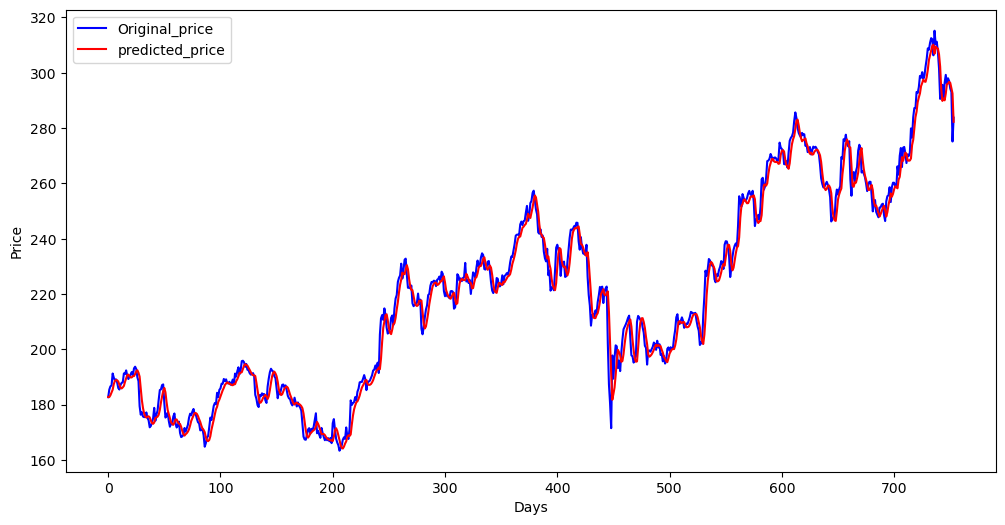

In [46]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original_price')
plt.plot(y_predicted,'r',label='predicted_price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(160.0, 320.0)

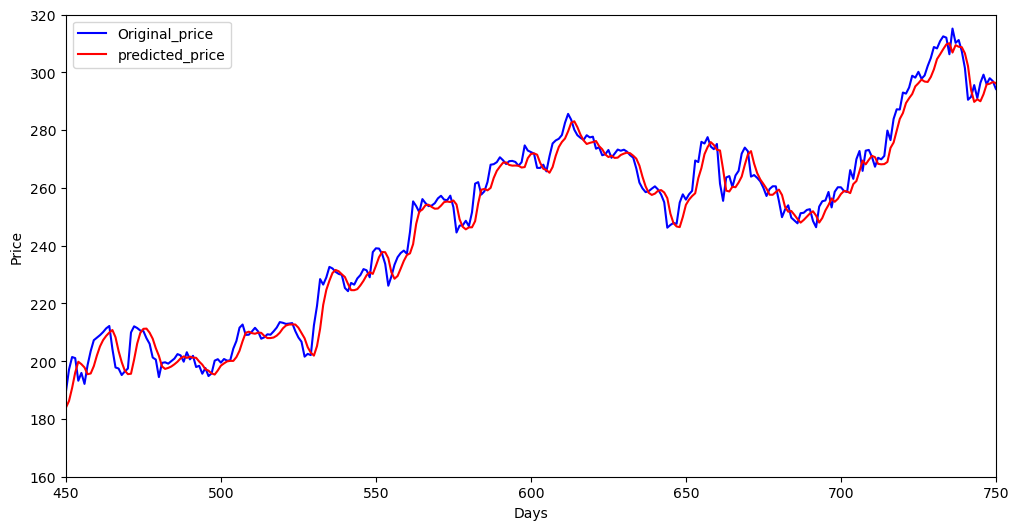

In [47]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original_price')
plt.plot(y_predicted,'r',label='predicted_price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450,750)
plt.ylim(160,320)

## Model Evaluation 

In [48]:
# Mean squared Error (MSE)
from sklearn.metrics import mean_squared_error,r2_score

In [49]:
mse = mean_squared_error(y_test,y_predicted)
print(f'Mean Squared Error (MSE) {mse}')

Mean Squared Error (MSE) 20.602855904617613


In [50]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root mean squared Error (RMSE) : {rmse}')

Root mean squared Error (RMSE) : 4.539036891744504


In [51]:
r2 = r2_score(y_test,y_predicted)
print(f'R-Squared: {r2}')

R-Squared: 0.9845581789978811
